In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')


In [16]:

df = pd.read_csv('Country-data.csv')
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [17]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [18]:

df.isnull().sum()


country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

In [19]:

df.describe()


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


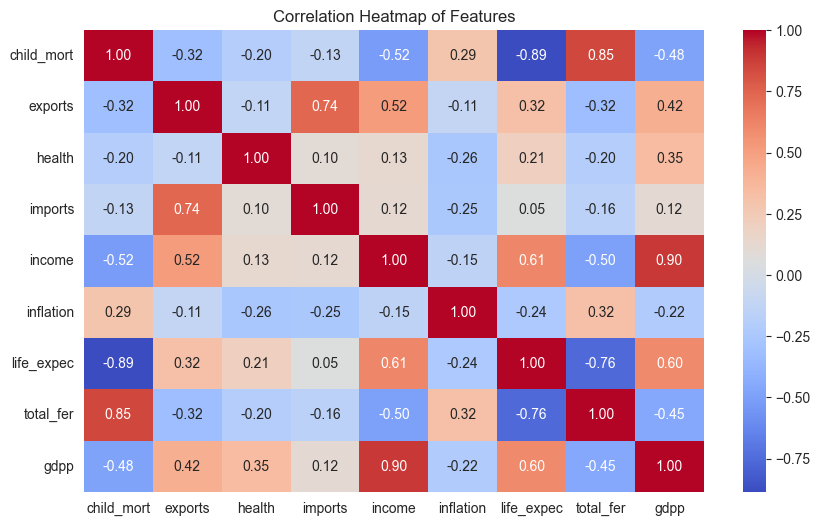

In [20]:
plt.figure(figsize=(10,6))
sns.heatmap(df.drop('country', axis=1).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Features')
plt.show()

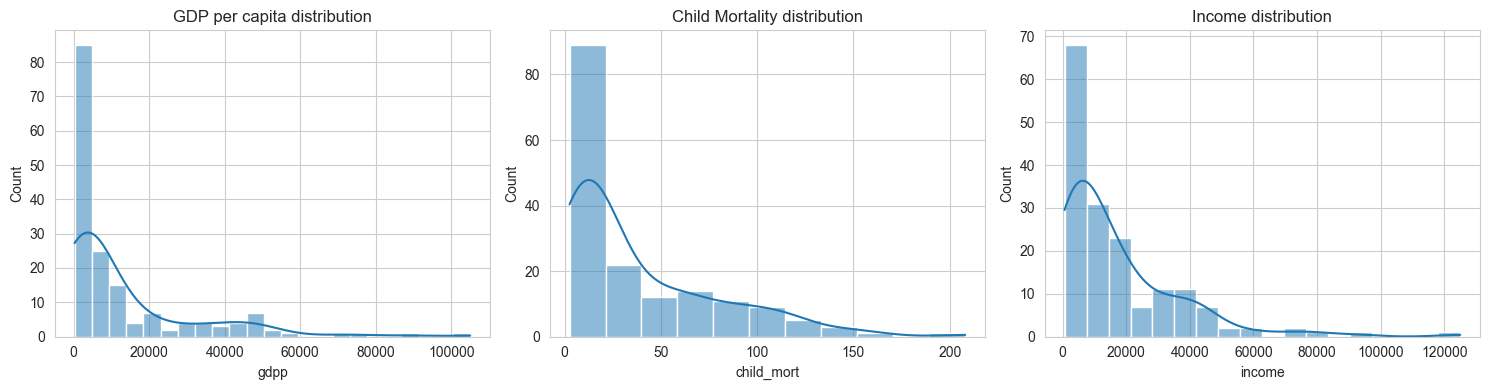

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
sns.histplot(df['gdpp'], kde=True, ax=axes[0])
axes[0].set_title('GDP per capita distribution')

sns.histplot(df['child_mort'], kde=True, ax=axes[1])
axes[1].set_title('Child Mortality distribution')

sns.histplot(df['income'], kde=True, ax=axes[2])
axes[2].set_title('Income distribution')

plt.tight_layout()
plt.show()

In [22]:
features = df.drop('country', axis=1)

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

scaled_df = pd.DataFrame(scaled_features, columns=features.columns)
scaled_df.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817


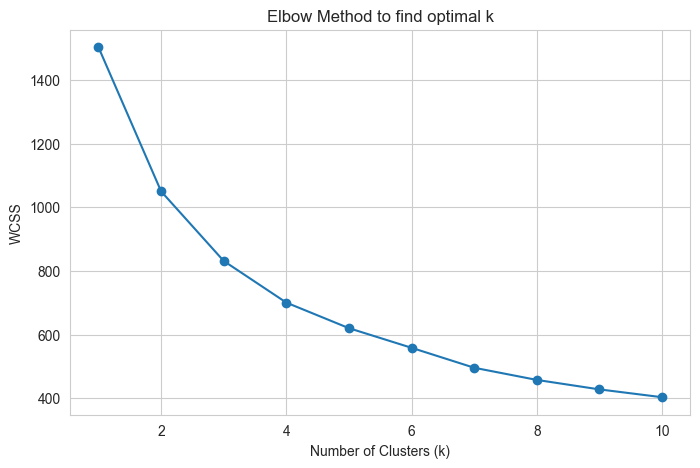

In [23]:
wcss = []
for k in range(1, 11):  # checking a couple more k values than before, just to be thorough
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.title('Elbow Method to find optimal k')
plt.show()

In [24]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster_kmeans'] = kmeans.fit_predict(scaled_features)

df['cluster_kmeans'].value_counts()

cluster_kmeans
2    84
1    47
0    36
Name: count, dtype: int64

In [25]:
df.groupby('cluster_kmeans')[['child_mort', 'income', 'gdpp', 'life_expec']].mean()

,child_mort,income,gdpp,life_expec
cluster_kmeans,,,,
0,5.000000,45672.222222,42494.444444,80.127778
1,92.961702,3942.404255,1922.382979,59.187234
2,21.927381,12305.595238,6486.452381,72.814286


In [26]:
cluster_order = df.groupby('cluster_kmeans')['gdpp'].mean().sort_values().index.tolist()
label_map = {cluster_order[0]: 'Under-developed', cluster_order[1]: 'Developing', cluster_order[2]: 'Developed'}

df['development_label'] = df['cluster_kmeans'].map(label_map)
df[['country', 'gdpp', 'income', 'child_mort', 'cluster_kmeans', 'development_label']].head(10)

,country,gdpp,income,child_mort,cluster_kmeans,development_label
0,Afghanistan,553,1610,90.2,1,Under-developed
1,Albania,4090,9930,16.6,2,Developing
2,Algeria,4460,12900,27.3,2,Developing
3,Angola,3530,5900,119.0,1,Under-developed
4,Antigua and Barbuda,12200,19100,10.3,2,Developing
5,Argentina,10300,18700,14.5,2,Developing
6,Armenia,3220,6700,18.1,2,Developing
7,Australia,51900,41400,4.8,0,Developed
8,Austria,46900,43200,4.3,0,Developed
9,Azerbaijan,5840,16000,39.2,2,Developing


In [27]:
df['development_label'].value_counts()

development_label
Developing         84
Under-developed    47
Developed          36
Name: count, dtype: int64

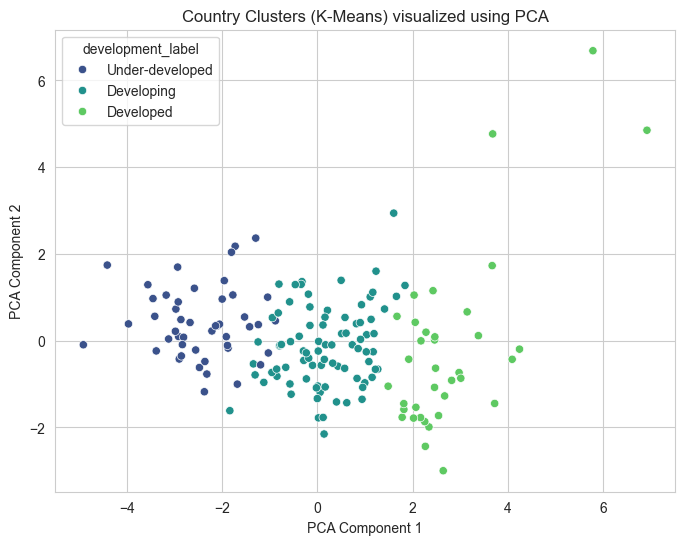

In [28]:
pca = PCA(n_components=2)
pca_features = pca.fit_transform(scaled_features)

plt.figure(figsize=(8,6))
sns.scatterplot(x=pca_features[:,0], y=pca_features[:,1], hue=df['development_label'], palette='viridis')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Country Clusters (K-Means) visualized using PCA')
plt.show()

In [29]:
dbscan = DBSCAN(eps=1.2, min_samples=5)
df['cluster_dbscan'] = dbscan.fit_predict(scaled_features)

df['cluster_dbscan'].value_counts()


cluster_dbscan
 1    75
-1    53
 0    21
 2    18
Name: count, dtype: int64

In [30]:
X = features  # original (unscaled is fine for tree-based models)
y = df['development_label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print('Train size:', X_train.shape)
print('Test size:', X_test.shape)

Train size: (133, 9)
Test size: (34, 9)


In [31]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print('Random Forest Accuracy:', round(accuracy_score(y_test, rf_pred), 4))
print()
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.9412

                 precision    recall  f1-score   support

      Developed       0.88      1.00      0.93         7
     Developing       0.94      0.94      0.94        17
Under-developed       1.00      0.90      0.95        10

       accuracy                           0.94        34
      macro avg       0.94      0.95      0.94        34
   weighted avg       0.94      0.94      0.94        34



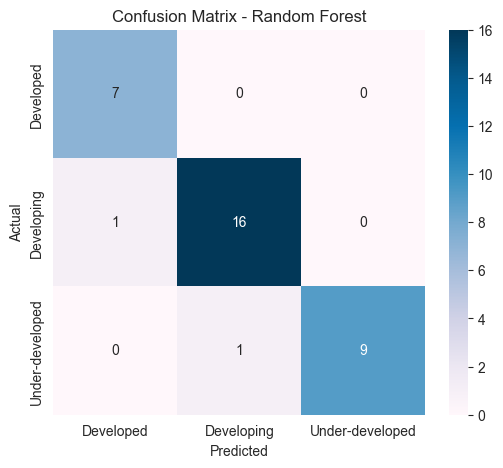

In [32]:
cm = confusion_matrix(y_test, rf_pred, labels=rf_model.classes_)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='PuBu', xticklabels=rf_model.classes_, yticklabels=rf_model.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')
plt.show()

In [33]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

xgb_model = XGBClassifier(n_estimators=120, random_state=42, use_label_encoder=False, eval_metric='mlogloss')  # slightly more trees than the RF model
xgb_model.fit(X_train, y_train_enc)

xgb_pred = xgb_model.predict(X_test)

print('XGBoost Accuracy:', round(accuracy_score(y_test_enc, xgb_pred), 4))
print()
print(classification_report(y_test_enc, xgb_pred, target_names=le.classes_))

XGBoost Accuracy: 0.9412

                 precision    recall  f1-score   support

      Developed       0.88      1.00      0.93         7
     Developing       0.94      0.94      0.94        17
Under-developed       1.00      0.90      0.95        10

       accuracy                           0.94        34
      macro avg       0.94      0.95      0.94        34
   weighted avg       0.94      0.94      0.94        34



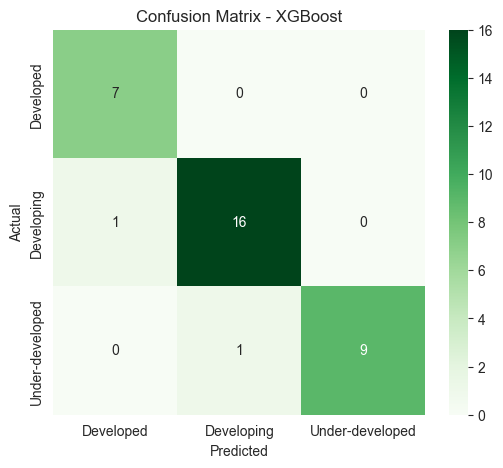

In [34]:
cm_xgb = confusion_matrix(y_test_enc, xgb_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost')
plt.show()

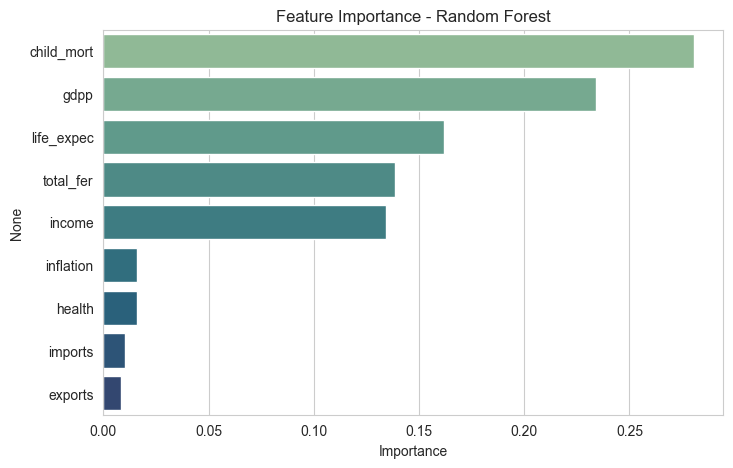

In [35]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=importances.values, y=importances.index, palette='crest')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance')
plt.show()
